In [2]:

# Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load the Dataset
df = pd.read_csv("World_Bank_Data.csv")
df.head()
df.shape

(1305, 20)

In [9]:
# Data Cleaning

df.replace("..", np.nan, inplace=True)
df.drop_duplicates(inplace=True)

# Convert year columns:
year_columns = df.columns[4:]

df[year_columns] = df[year_columns].apply(
    pd.to_numeric,
    errors="coerce"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1303 entries, 0 to 1304
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   1302 non-null   object 
 1   Country Code   1300 non-null   object 
 2   Series Name    1300 non-null   object 
 3   Series Code    1300 non-null   object 
 4   2010 [YR2010]  1113 non-null   float64
 5   2011 [YR2011]  1111 non-null   float64
 6   2012 [YR2012]  1120 non-null   float64
 7   2013 [YR2013]  1143 non-null   float64
 8   2014 [YR2014]  1142 non-null   float64
 9   2015 [YR2015]  1146 non-null   float64
 10  2016 [YR2016]  1155 non-null   float64
 11  2017 [YR2017]  1152 non-null   float64
 12  2018 [YR2018]  1156 non-null   float64
 13  2019 [YR2019]  1150 non-null   float64
 14  2020 [YR2020]  1145 non-null   float64
 15  2021 [YR2021]  1116 non-null   float64
 16  2022 [YR2022]  1097 non-null   float64
 17  2023 [YR2023]  1051 non-null   float64
 18  2024 [YR2024]

In [40]:
df_long = df.melt(
    id_vars=[
        "Country Name",
        "Country Code",
        "Series Name",
        "Series Code"
    ],
    var_name="Year",
    value_name="Value"
)
# Extract the 4-digit year from values like "2010 [YR2010]"
df_long["Year"] = df_long["Year"].str.extract(r'(\d{4})')

# Convert to integer
df_long["Year"] = pd.to_numeric(df_long["Year"])

# Remove rows where Year couldn't be extracted
df_long.dropna(subset=["Year"], inplace=True)

df_long["Year"] = df_long["Year"].astype(int)

df_long.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  20832 non-null  object 
 1   Country Code  20800 non-null  object 
 2   Series Name   20800 non-null  object 
 3   Series Code   20800 non-null  object 
 4   Year          20848 non-null  int64  
 5   Value         17333 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 977.4+ KB


In [41]:
df_long.dropna(subset=["Value"], inplace=True)
df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

In [42]:
df_ml = df_long.pivot_table(
    index=[
        "Country Name",
        "Country Code",
        "Year"
    ],
    columns="Series Name",
    values="Value"
).reset_index()

In [43]:
numeric_cols = df_ml.select_dtypes(include=np.number).columns

df_ml[numeric_cols] = df_ml[numeric_cols].fillna(
    df_ml[numeric_cols].median()
)

In [44]:
df_ml.shape

(320, 68)

In [45]:
df_ml.head()

Series Name,Country Name,Country Code,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Agriculture, forestry, and fishing, value added (% of GDP)","Agriculture, forestry, and fishing, value added (annual % growth)","Annual freshwater withdrawals, total (% of internal resources)",Births attended by skilled health staff (% of total),"Central government debt, total (% of GDP)","Contraceptive prevalence, any method (% of married women ages 15-49)",...,"School enrollment, secondary (% gross)","Services, value added (% of GDP)","Services, value added (annual % growth)",Surface area (sq. km),Tax revenue (% of GDP),Terrestrial and marine protected areas (% of total territorial area),"Total debt service (% of exports of goods, services and primary income)","Unemployment, total (% of total labor force) (modeled ILO estimate)","Unemployment, total (% of total labor force) (national estimate)",Urban population growth (annual %)
0,Argentina,ARG,2010,65.927,7.132167,39.523978,12.679008,95.0,49.93106,66.93000,...,99.070999,51.495180,7.089824,2780400.0,12.853043,14.7,18.642455,7.714,7.714,1.245680
1,Argentina,ARG,2011,66.764,6.998734,-2.428483,12.907534,97.1,49.93106,66.93000,...,100.884560,51.811901,6.444827,2780400.0,12.663628,14.7,15.654928,7.180,7.180,1.190193
2,Argentina,ARG,2012,64.852,5.781744,-12.875153,12.907534,98.2,49.93106,66.93000,...,102.709991,53.658118,0.668753,2780400.0,12.952842,14.7,14.066678,7.217,7.217,1.133954
3,Argentina,ARG,2013,66.104,6.052918,11.476620,12.907534,97.0,49.93106,72.37021,...,104.540863,53.919094,1.909762,2780400.0,12.452903,5.0,17.137319,7.100,7.100,1.099618
4,Argentina,ARG,2014,66.613,6.712704,3.104253,12.907534,99.6,49.93106,66.93000,...,106.038902,52.940543,-1.644378,2780400.0,12.610967,7.3,20.169582,7.268,7.268,1.136926


In [46]:
selected_columns = [
    "Country Name",
    "Country Code",
    "Year",
    "GDP growth (annual %)",
    "GDP (current US$)",
    "Gross capital formation (% of GDP)",
    "Gross savings (% of GDP)",
    "Inflation, consumer prices (annual %)",
    "Exports of goods and services (% of GDP)",
    "Imports of goods and services (% of GDP)",
    "Foreign direct investment, net inflows (% of GDP)",
    "Current account balance (% of GDP)",
    "Real interest rate (%)",
    "Domestic credit to private sector (% of GDP)",
    "Central government debt, total (% of GDP)",
    "Population growth (annual %)",
    "Population, total",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)"
]

df_project = df_ml[selected_columns].copy()

In [47]:
df_project.isnull().sum()

Series Name
Country Name                                                           0
Country Code                                                           0
Year                                                                   0
GDP growth (annual %)                                                  0
GDP (current US$)                                                      0
Gross capital formation (% of GDP)                                     0
Gross savings (% of GDP)                                               0
Inflation, consumer prices (annual %)                                  0
Exports of goods and services (% of GDP)                               0
Imports of goods and services (% of GDP)                               0
Foreign direct investment, net inflows (% of GDP)                      0
Current account balance (% of GDP)                                     0
Real interest rate (%)                                                 0
Domestic credit to private sector (% of

In [48]:
numeric_cols = df_project.select_dtypes(include='number').columns

df_project[numeric_cols] = df_project[numeric_cols].fillna(
    df_project[numeric_cols].median()
)

In [50]:
X = df_project.drop(columns=[
    "Country Name",
    "Country Code",
    "Year",
    "GDP growth (annual %)"
])

y = df_project["GDP growth (annual %)"]
print(X.shape)
print(y.shape)

(320, 14)
(320,)


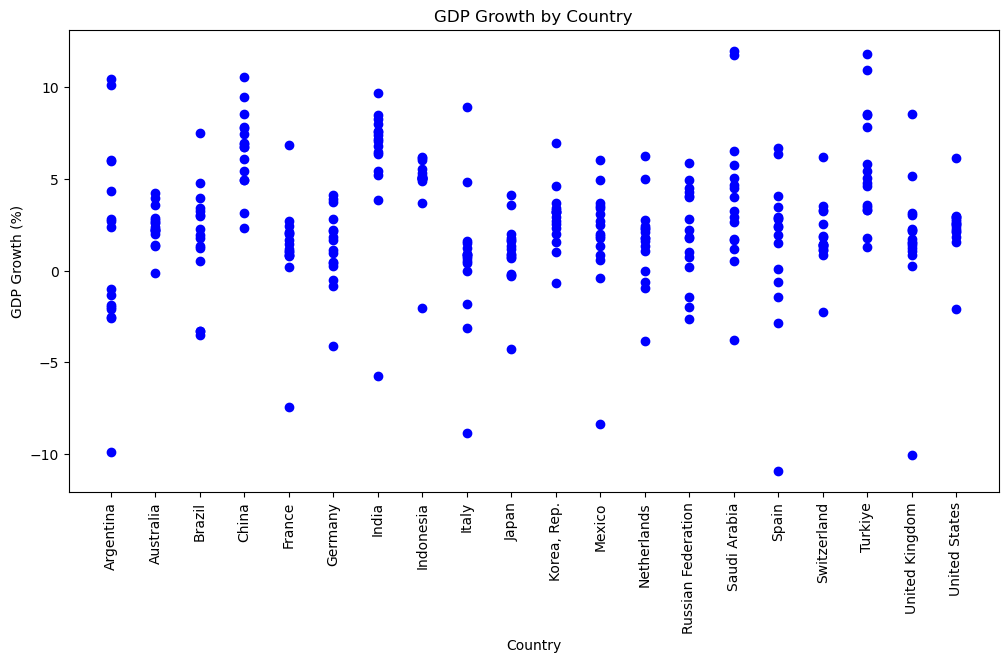

In [51]:
plt.figure(figsize=(12,6))

plt.scatter(
    df_project["Country Name"],
    df_project["GDP growth (annual %)"],
    color="blue"
)

plt.xticks(rotation=90)

plt.xlabel("Country")
plt.ylabel("GDP Growth (%)")
plt.title("GDP Growth by Country")

plt.show()

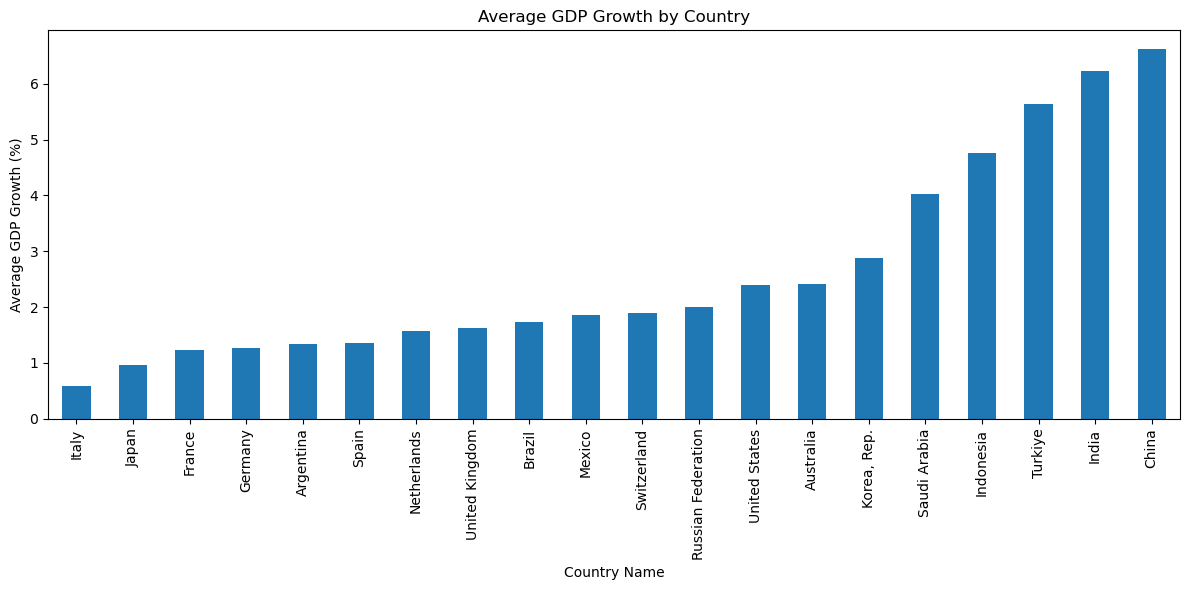

In [52]:
country_gdp = df_project.groupby("Country Name")["GDP growth (annual %)"].mean()

plt.figure(figsize=(12,6))

country_gdp.sort_values().plot(kind="bar")

plt.ylabel("Average GDP Growth (%)")
plt.title("Average GDP Growth by Country")

plt.tight_layout()

plt.show()

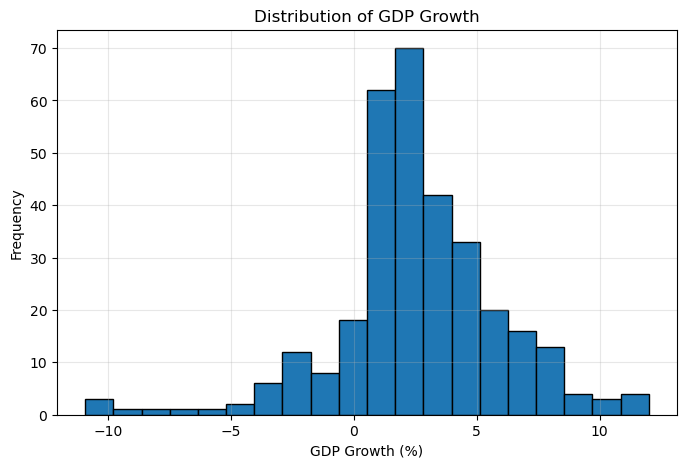

In [54]:
plt.figure(figsize=(8,5))

plt.hist(df_project["GDP growth (annual %)"],
         bins=20,
         edgecolor="black")

plt.title("Distribution of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

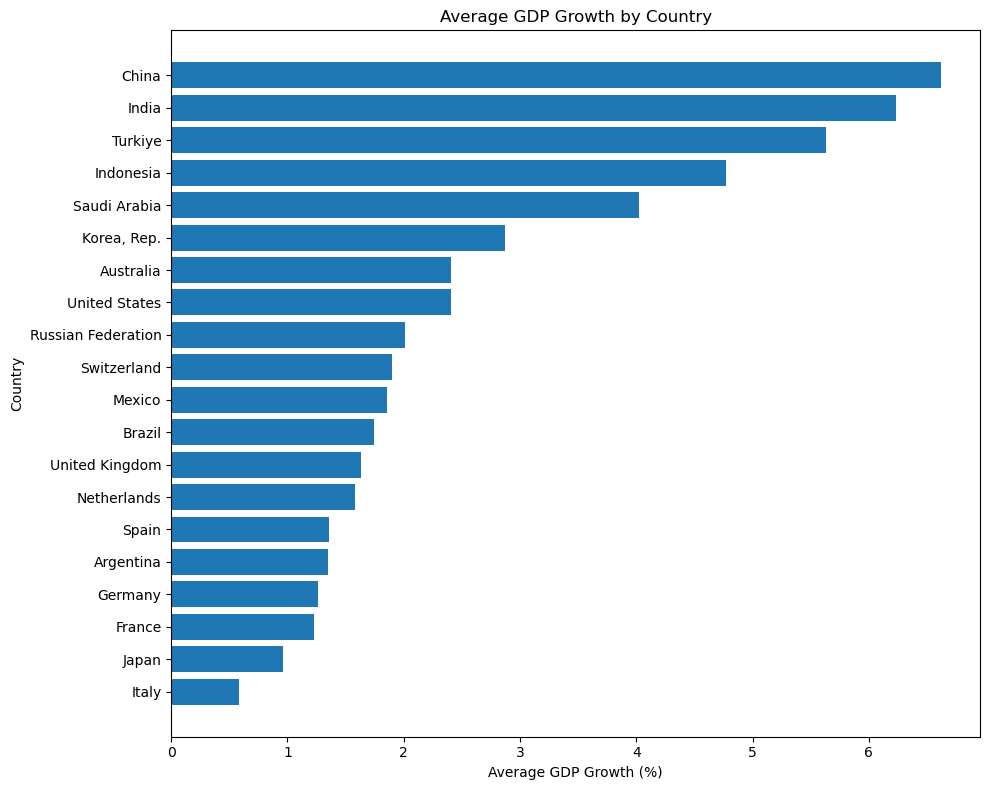

In [55]:
country_gdp = (
    df_project
    .groupby("Country Name")["GDP growth (annual %)"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,8))

plt.barh(country_gdp.index,
         country_gdp.values)

plt.xlabel("Average GDP Growth (%)")
plt.ylabel("Country")
plt.title("Average GDP Growth by Country")

plt.tight_layout()

plt.show()

In [58]:
df_project["Risk Score"] = (
    0.4 * df_project["Inflation, consumer prices (annual %)"] +
    0.3 * df_project["Central government debt, total (% of GDP)"] -
    0.3 * df_project["GDP growth (annual %)"]
)
country_risk = (
    df_project
    .groupby("Country Name")["Risk Score"]
    .mean()
    .sort_values(ascending=False)
)

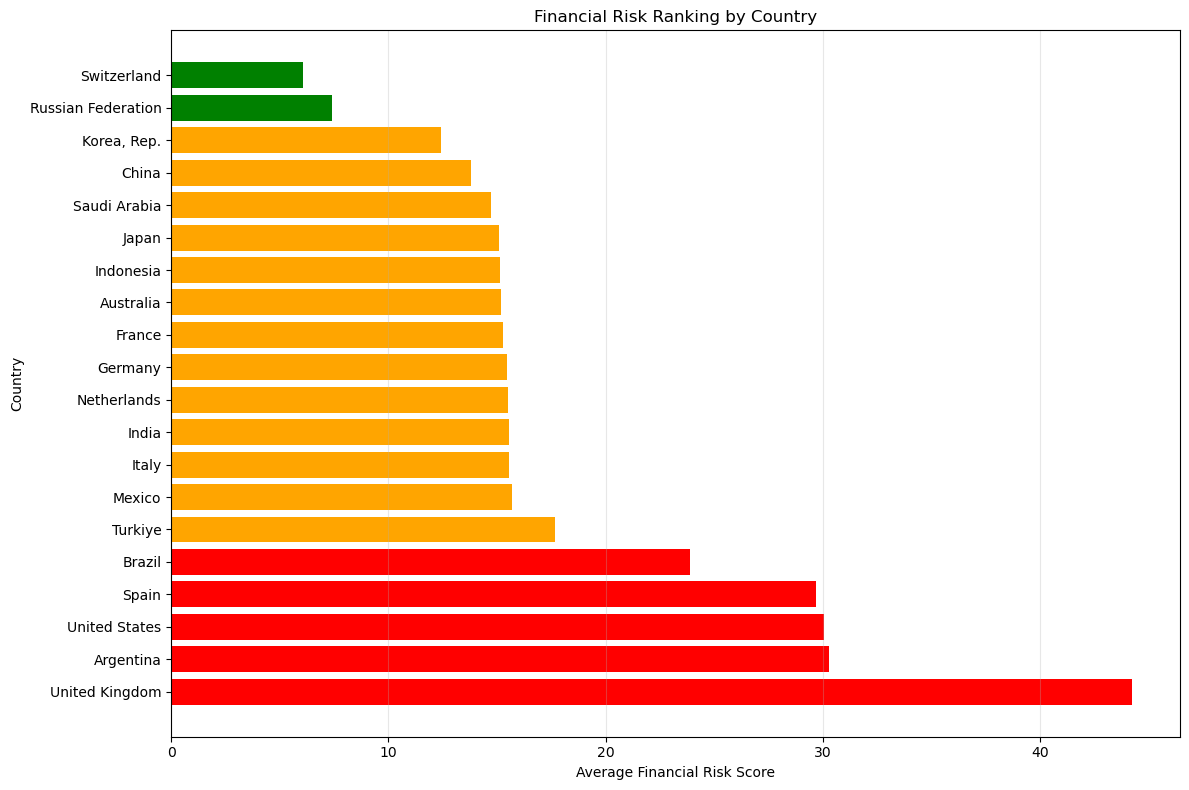

In [62]:
colors = [
    "red" if score > 20
    else "orange" if score > 10
    else "green"
    for score in country_risk.values
]

plt.figure(figsize=(12,8))

plt.barh(
    country_risk.index,
    country_risk.values,
    color=colors
)

plt.xlabel("Average Financial Risk Score")
plt.ylabel("Country")
plt.title("Financial Risk Ranking by Country")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# Report : The graph ranks countries based on their average financial risk score calculated using inflation, government debt, and GDP growth. Countries with higher scores indicate greater macroeconomic financial risk, while countries with lower scores demonstrate relatively stronger economic stability during the study period.